I uppgift 6.7 ska vi klustra hus i Kalifornien baserat på geografi och inkomst

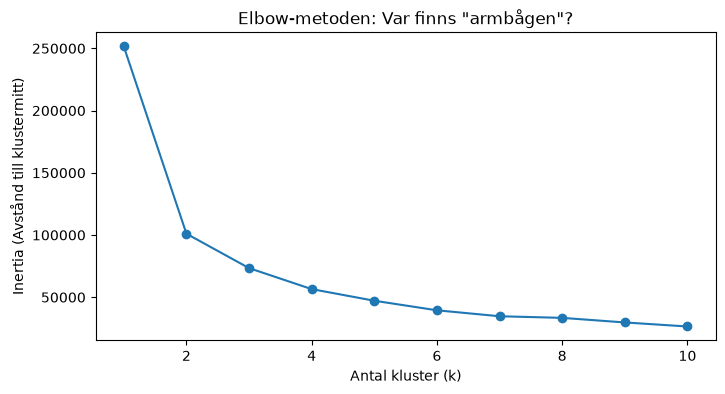

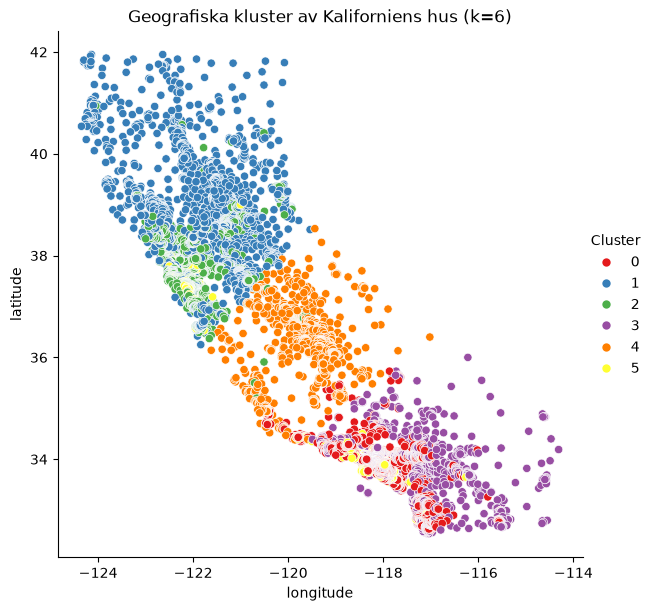

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Läs in datan 
df = pd.read_csv("housing.csv")

# 2. Välj inkomst och geografisk plats
X = df.loc[:, ["median_income", "latitude", "longitude"]]

# --- Del D: Hitta optimalt antal kluster med Elbow-metoden ---
inertias = []
for k in range(1, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_temp.fit(X)
    inertias.append(kmeans_temp.inertia_)

# Rita upp Elbow-grafen
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow-metoden: Var finns "armbågen"?')
plt.xlabel('Antal kluster (k)')
plt.ylabel('Inertia (Avstånd till klustermitt)')
plt.show()

# --- Den ursprungliga koden med 6 kluster ---
kmeans = KMeans(n_clusters=6, random_state=42, n_init='auto')
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")

# Karta över Kalifornien med våra 6 kluster
sns.relplot(x="longitude", y="latitude", hue="Cluster", data=X, height=6, palette="Set1")
plt.title('Geografiska kluster av Kaliforniens hus (k=6)')
plt.show()